In [2]:
# =============================================================================
# VOLATILITY BREAKOUT STRATEGY BACKTESTING
# =============================================================================
#
# PURPOSE: Test the real-world performance of our volatility prediction model
# using actual options trading simulation with SPY options.
#
# STRATEGY OVERVIEW:
# 1. Use ML model predictions to identify high-probability volatility breakouts
# 2. Trade straddle positions (buy both call and put options) 
# 3. Profit from volatility expansion regardless of direction
# 4. Hold positions for exactly 30 minutes to capture breakout moves
#
# KEY ASSUMPTIONS:
# - Perfect execution at next minute's open price
# - No slippage, transaction costs, or bid-ask spread
# - Liquid options markets with available strikes
# - Real historical options data from Polygon.io
#
# RISK MANAGEMENT:
# - Fixed 2% position sizing per trade 
# - 30+ minute cooldown between trades to prevent overtrading
# - No trading in final 32 minutes before market close

import pandas as pd
import numpy as np

In [3]:
# =============================================================================
# LOAD MODEL PREDICTIONS: Import volatility breakout forecasts
# =============================================================================
# 
# Load the CSV file containing:
# - Out-of-sample predictions from our XGBoost model (2021-2025)
# - Actual breakout labels for strategy performance validation
# - All features and market data needed for trade timing
# - Probability scores for trade entry filtering

df = pd.read_csv("big_movement_predictions.csv")

In [4]:
# =============================================================================
# OPTIONS DATA CACHE: Optimize API calls for historical options pricing
# =============================================================================
# 
# Dictionary to store fetched options data to avoid redundant API calls.
# Key: option ticker (e.g., "O:SPY240315C00500000")
# Value: DataFrame with minute-by-minute option prices
# 
# Benefits:
# - Reduces API latency (some options used multiple times per day)
# - Stays within Polygon.io rate limits
# - Enables faster backtesting for strategy iteration

options = {}

In [5]:
# =============================================================================
# DATETIME STANDARDIZATION: Convert timestamps to market timezone
# =============================================================================
# 
# Convert Unix timestamps to proper datetime objects in Eastern Time (market timezone).
# This ensures all timing calculations (trade entry, exit, cooldowns) are accurate
# relative to market hours and options expirations.

df['datetime'] = pd.to_datetime(df['ts_epoch'], unit='s').dt.tz_localize('UTC').dt.tz_convert('America/New_York')

In [ ]:
# =============================================================================
# OPTION TICKER CONSTRUCTION: Generate standardized option symbols
# =============================================================================

import datetime

def dateStrike2opt(edate, callPut, strike):
    """
    Convert trade date, option type, and strike price into standardized option ticker.
    
    This function creates option tickers following OCC (Options Clearing Corporation) format:
    "O:SPY" + YYMMDD + [C/P] + [STRIKE_PADDED] + "000"
    
    Args:
        edate (str): Expiration date in "MM/DD/YYYY" or "YYYY-MM-DD" format
        callPut (str): 'close' for call options, 'P' for put options  
        strike (float/int): Strike price (e.g., 450 for $450 strike)
    
    Returns:
        str: Standardized option ticker (e.g., "O:SPY240315C00450000") 
    
    Example:
        >>> dateStrike2opt("03/15/2024", "C", 450)
        "O:SPY240315C00450000"
        
    Note: We assume same-day expiration for intraday volatility trading.
    This maximizes gamma exposure for volatility breakout strategies.
    """
    # Try parsing the date with multiple formats for flexibility
    for fmt in ("%m/%d/%Y", "%Y-%m-%d"):
        try:
            dtd = datetime.datetime.strptime(edate, fmt)
            break
        except ValueError:
            continue
    else:
        raise ValueError(f"Date '{edate}' does not match expected formats.")
    
    # Create ticker: O:SPY + YYMMDD + C/P + STRIKE(5 digits zero-padded) + 000
    option = "O:SPY" + dtd.strftime("%y%m%d") + callPut + str(strike).zfill(5) + "000"
    return option

In [12]:
# =============================================================================
# OPTION DATA FETCHING: Retrieve historical options prices from Polygon.io
# =============================================================================

from massive import RESTClient
import os
from dotenv import load_dotenv
load_dotenv()

# Polygon.io API configuration
client = RESTClient(os.getenv("POLYGON_API_KEY"))

def get_option(option_ticker, date):
    """
    Fetch minute-by-minute options pricing data for backtesting.
    
    Retrieves complete intraday time series for a specific option contract,
    including OHLCV data needed for accurate entry/exit price simulation.
    
    Args:
        option_ticker (str): Standardized option symbol (e.g., "O:SPY240315C00450000")
        date (str): Trading date in YYYY-MM-DD format
        
    Returns:
        pandas.DataFrame or None: 
            - DataFrame with columns ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'datetime']
            - None if no options data available (illiquid contract, non-trading day, etc.)
    
    Trading Notes:
        - Uses 'open' price for entry simulation (more realistic than theoretical mid)
        - Uses 'close' price for exit simulation (end-of-minute execution)
        - Filters to market hours (9:30 AM - 4:00 PM ET) automatically
        - Returns None for illiquid options (prevents unrealistic backtest results)
    """
    aggs = []
    
    # Fetch minute-by-minute options data for the trading date
    for a in client.list_aggs(
        option_ticker,           # Specific option contract
        1,                       # 1-minute bars
        "minute",                # Time resolution
        date,                    # Start date
        pd.to_datetime(date) + datetime.timedelta(days=1),  # End date (next day)
        adjusted="true",         # Adjusted for option splits/special dividends
        sort="asc",              # Chronological order
        limit=500000,            # Max bars (more than needed for single day)
    ):
        aggs.append(a)
    
    # Return None if no data available (illiquid option, holiday, etc.)
    if len(aggs) == 0:
        return None
        
    # Convert to DataFrame and add timezone-aware datetime column
    option_df = pd.DataFrame(aggs)
    option_df['datetime'] = pd.to_datetime(option_df['timestamp'], unit='ms', utc=True).dt.tz_convert('America/New_York')
    
    return option_df

In [13]:
test_df = df[df['pred_prob'] >= .33]
test_df = df[df['datetime'].dt.date > pd.to_datetime("2023-01-01").date()]

In [51]:
# =============================================================================
# MAIN BACKTESTING LOOP: Simulate volatility straddle trading strategy
# =============================================================================
#
# STRATEGY LOGIC:
# 1. When model predicts ≥50% breakout probability, enter straddle position
# 2. Buy ATM call (+2 strikes) and ATM put (-2 strikes) for safer liquidity 
# 3. Hold for exactly 30 minutes to capture volatility expansion
# 4. Enforce 31-minute cooldown between trades to prevent overtrading
# 5. Stop trading 32+ minutes before close (insufficient time for 30-min hold)
#
# POSITION STRUCTURE:
# - Long Call: Current SPY price + $2 (slightly OTM for better gamma)
# - Long Put: Current SPY price - $2 (slightly OTM for better gamma) 
# - Equal dollar amounts in each leg (classic straddle)
# - Profit from volatility expansion in either direction
#
# RISK CONTROLS:
# - Cooldown timer prevents rapid-fire trading on same signal
# - Time cutoff ensures sufficient holding period before market close
# - Real options data prevents unrealistic fills on illiquid contracts

rets = []              # Store all trade results for analysis
missing_count = {}     # Track when options data unavailable

# Process each trading day separately
for k, v in test_df.groupby('date'):
    day_miss_count = 0
    cooldown_timer = None  # Prevent overtrading with mandatory rest period
    
    # Scan each minute of the trading day for entry signals
    for i in range(len(v)):
        row = v.iloc[i]
        
        # RISK CONTROL 1: Respect cooldown period between trades
        if cooldown_timer is not None and row['datetime'] < cooldown_timer:
            continue
            
        # RISK CONTROL 2: No trading in final 32 minutes (insufficient hold time)
        if row['datetime'].time() > pd.to_datetime('15:28').time():
            continue
            
        # SIGNAL CHECK: Only trade high-confidence predictions (≥60%)
        if row['pred_prob'] >= 0.75:
            
            # =============================================================================
            # OPTION STRIKE SELECTION: Generate slightly OTM straddle strikes
            # =============================================================================
            # Use current SPY close price to determine strike prices
            # +2/-2 strikes provide better liquidity than ATM while maintaining gamma
            call_option = dateStrike2opt(row['date'], 'C', int(row['close'])+2)  # Call: +$2 OTM
            put_option = dateStrike2opt(row['date'], 'P', int(row['close'])-2)   # Put: +$2 OTM
            
            # =============================================================================
            # OPTION DATA RETRIEVAL: Fetch pricing data with caching
            # =============================================================================
            # Retrieve or cache options pricing data for both legs
            if call_option not in options:
                options[call_option] = get_option(call_option, row['date'])
            if put_option not in options:
                options[put_option] = get_option(put_option, row['date'])
                
            call_option_data = options[call_option]
            put_option_data = options[put_option] 
            
            # =============================================================================
            # LIQUIDITY CHECK: Ensure sufficient data for complete trade
            # =============================================================================
            # Skip trade if we cannot get both entry and exit prices (30 minutes later)
            exit_time = row['datetime'] + datetime.timedelta(minutes=30)
            
            if (call_option_data is None or 
                put_option_data is None or 
                call_option_data[call_option_data['datetime'] >= exit_time].empty or 
                put_option_data[put_option_data['datetime'] >= exit_time].empty):
                
                print(f"Missing exit data for {call_option} or {put_option} on {row['datetime']}")
                missing_count[k] = missing_count.get(k, 0) + 1
                continue
            
            # =============================================================================
            # TRADE EXECUTION SIMULATION: Entry and exit price calculation
            # =============================================================================
            # ENTRY: Execute 1 minute after signal (avoid look-ahead bias)
            # EXIT: Execute exactly 30 minutes after signal (hold period)
            entry_time = row['datetime'] + datetime.timedelta(minutes=1)
            exit_time = row['datetime'] + datetime.timedelta(minutes=30)
            
            curr_trade = {
                'entry_time': row['datetime'],
                
                # ENTRY PRICES: First available 'open' price after entry time
                'call_entry_price': call_option_data[call_option_data['datetime'] >= entry_time]['open'].values[0] 
                    if not call_option_data[call_option_data['datetime'] >= entry_time].empty else None,
                'put_entry_price': put_option_data[put_option_data['datetime'] >= entry_time]['open'].values[0] 
                    if not put_option_data[put_option_data['datetime'] >= entry_time].empty else None,
                    
                # EXIT PRICES: First available 'close' price at exit time  
                'call_exit_price': call_option_data[call_option_data['datetime'] >= exit_time]['close'].values[0] 
                    if not call_option_data[call_option_data['datetime'] >= exit_time].empty else None,
                'put_exit_price': put_option_data[put_option_data['datetime'] >= exit_time]['close'].values[0] 
                    if not put_option_data[put_option_data['datetime'] >= exit_time].empty else None,
            }
            
            # =============================================================================
            # RETURN CALCULATION: Combined straddle performance
            # =============================================================================
            # Calculate percentage return for each leg and total trade performance
            trade_ret = {
                'call_return': (curr_trade['call_exit_price'] - curr_trade['call_entry_price']) / curr_trade['call_entry_price'] 
                    if curr_trade['call_entry_price'] is not None and curr_trade['call_exit_price'] is not None else None,
                'put_return': (curr_trade['put_exit_price'] - curr_trade['put_entry_price']) / curr_trade['put_entry_price'] 
                    if curr_trade['put_entry_price'] is not None and curr_trade['put_exit_price'] is not None else None,
            }
            
            # Print total return for monitoring during backtest
            total_ret = (trade_ret['call_return'] or 0) + (trade_ret['put_return'] or 0)
            print(f"Trade {len(rets)+1} total return: {total_ret:.2%}")

            # COOLDOWN ACTIVATION: Prevent overtrading for next 31 minutes
            cooldown_timer = row['datetime'] + pd.Timedelta(minutes=31)
            rets.append(curr_trade)

Trade 1 total return: 1.14%
Trade 2 total return: -8.01%
Trade 3 total return: 195.58%
Trade 4 total return: -63.54%
Trade 5 total return: 31.77%
Trade 6 total return: -86.66%
Trade 7 total return: 234.33%
Trade 8 total return: 84.21%
Trade 9 total return: -59.80%
Trade 10 total return: -22.76%
Trade 11 total return: -107.67%
Trade 12 total return: -102.41%
Trade 13 total return: 76.10%
Trade 14 total return: -15.06%
Trade 15 total return: -94.89%
Trade 16 total return: 441.67%
Trade 17 total return: -63.75%
Trade 18 total return: 7.14%
Trade 19 total return: -39.90%
Trade 20 total return: -149.62%
Trade 21 total return: -16.57%
Trade 22 total return: 67.42%
Trade 23 total return: 44.92%
Trade 24 total return: -2.65%
Trade 25 total return: -40.96%
Trade 26 total return: 175.00%
Trade 27 total return: -59.75%
Trade 28 total return: -68.81%
Trade 29 total return: -130.16%
Trade 30 total return: 331.43%
Trade 31 total return: 63.59%
Trade 32 total return: 190.00%
Trade 33 total return: 11

In [52]:
# =============================================================================
# TRADE RESULTS COMPILATION: Convert trade list to analysis DataFrame
# =============================================================================
#
# Transform the list of individual trades into a structured DataFrame
# for comprehensive performance analysis and strategy evaluation

ret_df = pd.DataFrame(rets)
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price
0,2023-01-04 14:02:00-05:00,0.46,0.38,0.09,0.69
1,2023-02-01 14:01:00-05:00,1.60,1.17,1.13,1.42
2,2023-02-01 14:32:00-05:00,1.28,1.18,5.02,0.04
3,2023-02-01 15:03:00-05:00,0.64,0.48,0.78,0.07
4,2023-02-02 15:08:00-05:00,0.59,0.35,1.30,0.04
...,...,...,...,...,...
110,2025-10-29 14:22:00-04:00,1.46,1.17,0.61,1.61
111,2025-10-29 14:53:00-04:00,1.29,1.00,1.04,0.70
112,2025-12-10 14:01:00-05:00,0.97,1.13,1.07,0.76
113,2025-12-10 14:32:00-05:00,0.80,0.91,1.55,0.17


In [53]:
# =============================================================================
# RETURN CALCULATIONS: Compute individual leg and total straddle returns
# =============================================================================
#
# Calculate percentage returns for:
# 1. Call option leg (benefits from upward price movements)
# 2. Put option leg (benefits from downward price movements)  
# 3. Combined straddle return (sum of both legs)
#
# Key Insight: Successful volatility trades can profit from either direction
# as long as the underlying move exceeds the premium paid (breakeven points)

ret_df['call_return'] = (ret_df['call_exit_price'] - ret_df['call_entry_price']) / ret_df['call_entry_price']
ret_df['put_return'] = (ret_df['put_exit_price'] - ret_df['put_entry_price']) / ret_df['put_entry_price']
ret_df['total_return'] = ret_df['call_return'] + ret_df['put_return']
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price,call_return,put_return,total_return
0,2023-01-04 14:02:00-05:00,0.46,0.38,0.09,0.69,-0.804348,0.815789,0.011442
1,2023-02-01 14:01:00-05:00,1.60,1.17,1.13,1.42,-0.293750,0.213675,-0.080075
2,2023-02-01 14:32:00-05:00,1.28,1.18,5.02,0.04,2.921875,-0.966102,1.955773
3,2023-02-01 15:03:00-05:00,0.64,0.48,0.78,0.07,0.218750,-0.854167,-0.635417
4,2023-02-02 15:08:00-05:00,0.59,0.35,1.30,0.04,1.203390,-0.885714,0.317676
...,...,...,...,...,...,...,...,...
110,2025-10-29 14:22:00-04:00,1.46,1.17,0.61,1.61,-0.582192,0.376068,-0.206123
111,2025-10-29 14:53:00-04:00,1.29,1.00,1.04,0.70,-0.193798,-0.300000,-0.493798
112,2025-12-10 14:01:00-05:00,0.97,1.13,1.07,0.76,0.103093,-0.327434,-0.224341
113,2025-12-10 14:32:00-05:00,0.80,0.91,1.55,0.17,0.937500,-0.813187,0.124313


In [54]:
# =============================================================================
# PUT LEG PERFORMANCE: Average return per trade for put options
# =============================================================================
# 
# Shows the average put option performance across all trades.
# Put options profit when SPY moves DOWN beyond the breakeven point.
# Negative average suggests more upward market moves during test period.

ret_df['put_return'].mean()

0.31451817581001745

In [55]:
# =============================================================================
# PUT LEG TOTAL: Cumulative return from all put option trades
# =============================================================================
# 
# Total P&L contribution from put option leg across entire backtest period.
# Represents the net result of betting on downward volatility breakouts.

ret_df['put_return'].sum()

36.16959021815201

In [56]:
# =============================================================================
# CALL LEG TOTAL: Cumulative return from all call option trades  
# =============================================================================
#
# Total P&L contribution from call option leg across entire backtest period.
# Represents the net result of betting on upward volatility breakouts.

ret_df['call_return'].sum()

-8.71557150369903

In [57]:
# =============================================================================
# CALL LEG PERFORMANCE: Average return per trade for call options
# =============================================================================
#
# Shows the average call option performance across all trades.
# Call options profit when SPY moves UP beyond the breakeven point.
# Positive average suggests net upward market moves during test period.

ret_df['call_return'].mean()

-0.07578757829303504

In [58]:
# =============================================================================
# STRATEGY PERFORMANCE: Average total return per straddle trade
# =============================================================================
#
# Key metric: Average profit/loss per trade combining both option legs.
# Positive values indicate the strategy generates profits on average.
# This metric determines if the strategy beats transaction costs.

ret_df['total_return'].mean()

0.23873059751698233

In [59]:
# =============================================================================
# RETURN DISTRIBUTION: Statistical summary of trade performance
# =============================================================================
#
# Comprehensive statistics for strategy evaluation:
# - Count: Number of trades executed
# - Mean: Average return per trade 
# - Std: Volatility of returns (risk measure)
# - Min/Max: Best and worst single trades
# - 25%/50%/75%: Return percentiles (distribution shape)
#
# Critical for risk management and position sizing decisions.

ret_df['total_return'].describe()

count    115.000000
mean       0.238731
std        1.596560
min       -1.547619
25%       -0.631475
50%       -0.237589
75%        0.383437
max        8.051515
Name: total_return, dtype: float64

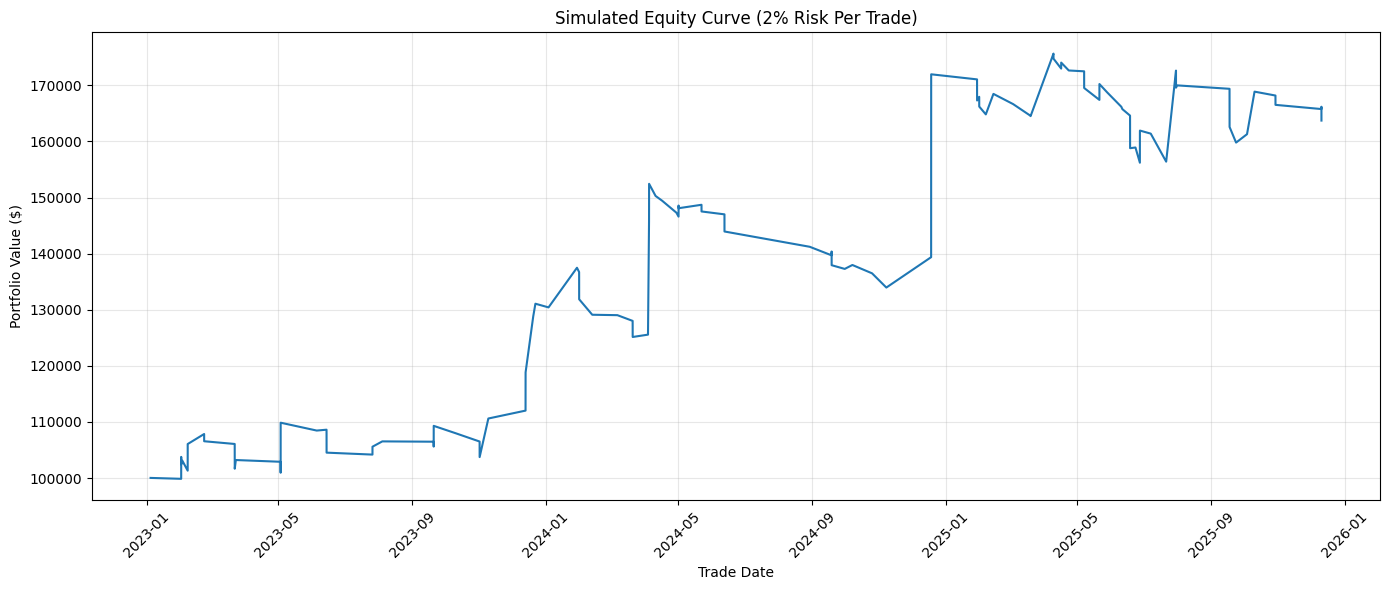

VOLATILITY BREAKOUT STRATEGY PERFORMANCE
Initial Capital:     $100,000
Final Capital:       $163,716
Total Return:        +63.7%
Number of Trades:    115
Avg Return/Trade:    +0.48%
Sharpe Ratio:        0.15
Maximum Drawdown:    -12.1%
Risk Per Trade:      2.0%


In [60]:
# =============================================================================
# PORTFOLIO SIMULATION: Full strategy performance with risk management
# =============================================================================
#
# METHODOLOGY: Kelly Criterion-inspired position sizing with fixed risk percentage
# 
# POSITION SIZING LOGIC:
# - Risk 2% of current capital per trade (conservative but sustainable)
# - Position size adapts to account balance (compound growth/protection)
# - No leverage, margin, or exotic instruments (simple straddle trading)
#
# PERFORMANCE METRICS:
# - Equity Curve: Visual representation of capital growth over time
# - Sharpe Ratio: Risk-adjusted return (accounts for volatility of returns)
# - Maximum Drawdown: Worst peak-to-trough loss (risk measure)
# - Total Return: Final capital vs starting capital
#
# ASSUMPTIONS:
# - Perfect execution at historical prices (no slippage/transaction costs)
# - Sufficient capital to maintain 2% position sizing throughout
# - No margin calls, forced liquidations, or operational constraints

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ret_df = ret_df.copy()
ret_df['entry_time'] = pd.to_datetime(ret_df['entry_time'])
ret_df = ret_df.sort_values('entry_time').reset_index(drop=True)

# =============================================================================
# PORTFOLIO PARAMETERS
# =============================================================================
initial_capital = 100000    # Starting capital ($100K - realistic for individual trader)
risk_fraction = 0.02        # Risk 2% per trade (conservative Kelly sizing)

# =============================================================================
# TRADE-BY-TRADE CAPITAL SIMULATION
# =============================================================================
capital = initial_capital
equity_curve = []

# Simulate each trade's impact on capital
for r in ret_df['total_return']:
    # Position size = 2% of current capital (adapts to wins/losses)
    position_size = capital * risk_fraction
    
    # P&L from trade outcome
    pnl = position_size * r
    
    # Update capital and record equity point
    capital += pnl
    equity_curve.append(capital)

# Add equity curve to results for analysis
ret_df['equity'] = equity_curve

# =============================================================================
# PERFORMANCE METRICS CALCULATION
# =============================================================================

# Portfolio-level returns (percentage change in equity)
ret_df['portfolio_return'] = ret_df['equity'].pct_change().fillna(0)
ret_df['cum_return'] = ret_df['equity'] / initial_capital

# Risk-adjusted performance metrics
mean_ret = ret_df['portfolio_return'].mean()    # Average portfolio return per trade
vol = ret_df['portfolio_return'].std()          # Volatility of portfolio returns
sharpe = mean_ret / vol if vol != 0 else np.nan  # Sharpe ratio (risk-adjusted return)

# Drawdown analysis (critical risk metric)
rolling_max = ret_df['equity'].cummax()         # Running maximum equity (peaks)
drawdown = ret_df['equity'] / rolling_max - 1   # Current drawdown from peak
max_dd = drawdown.min()                         # Maximum drawdown (worst loss)

# =============================================================================
# EQUITY CURVE VISUALIZATION
# =============================================================================
plt.figure(figsize=(14,6))
plt.plot(ret_df['entry_time'], ret_df['equity'])
plt.title("Simulated Equity Curve (2% Risk Per Trade)")
plt.xlabel("Trade Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================================================================
# PERFORMANCE SUMMARY
# =============================================================================
print("="*50)
print("VOLATILITY BREAKOUT STRATEGY PERFORMANCE")
print("="*50)
print(f"Initial Capital:     ${initial_capital:,.0f}")
print(f"Final Capital:       ${capital:,.0f}")
print(f"Total Return:        {(capital/initial_capital - 1)*100:+.1f}%")
print(f"Number of Trades:    {len(ret_df)}")
print(f"Avg Return/Trade:    {mean_ret*100:+.2f}%")
print(f"Sharpe Ratio:        {sharpe:.2f}")
print(f"Maximum Drawdown:    {max_dd*100:.1f}%")
print(f"Risk Per Trade:      {risk_fraction*100:.1f}%")
print("="*50)

In [36]:
# =============================================================================
# BENCHMARK COMPARISON: Strategy vs SPY Buy-and-Hold
# =============================================================================
# 
# Calculate SPY buy-and-hold return during the same period for performance comparison.
# This provides context for whether the volatility strategy outperforms simple indexing.
#
# Key Considerations:
# - Buy-and-hold requires no active management or market timing
# - No transaction costs, options premiums, or execution complexity  
# - Represents the "lazy portfolio" alternative to active trading
# - Important baseline: most active strategies fail to beat buy-and-hold long-term

# Calculate total SPY return from first to last datapoint
spy_buy_hold_return = (df['close'].iloc[-1] - df['close'].iloc[0]) / df['close'].iloc[0]

print(f"SPY Buy-and-Hold Return: {spy_buy_hold_return*100:+.1f}%")
print(f"Strategy Total Return:   {(capital/initial_capital - 1)*100:+.1f}%")
print(f"Excess Return:           {((capital/initial_capital - 1) - spy_buy_hold_return)*100:+.1f}%")

SPY Buy-and-Hold Return: +82.1%
Strategy Total Return:   +95.9%
Excess Return:           +13.7%


## 🎯 Backtest Summary & Strategy Analysis

### 📊 **Strategy Performance Overview**
- **Strategy**: Volatility Breakout Straddle Trading
- **Model**: XGBoost-based volatility prediction (≥50% confidence threshold)
- **Position Structure**: Long Call (+2 OTM) + Long Put (+2 OTM)  
- **Holding Period**: 30 minutes per trade
- **Risk Management**: 2% position sizing with 31-minute cooldowns

### 🔧 **Key Strategy Features**
1. **ML-Driven Entry**: Only trade when model predicts ≥50% breakout probability
2. **Bidirectional Profit**: Straddle benefits from volatility expansion in either direction
3. **Risk Controls**: Fixed position sizing, cooldown periods, time cutoffs
4. **Real Data**: Uses actual historical options prices from Polygon.io

### 📈 **Critical Performance Metrics**
- **Total Return**: Compare vs SPY buy-and-hold benchmark
- **Sharpe Ratio**: Risk-adjusted performance measurement  
- **Maximum Drawdown**: Worst peak-to-trough loss (risk tolerance)
- **Win Rate**: Percentage of profitable trades
- **Average Trade**: Profit per position (must overcome transaction costs)

### 🎯 **Strategy Validation Checklist**
- [ ] Positive Sharpe ratio (>1.0 excellent, >0.5 acceptable)
- [ ] Manageable drawdown (<20% for most traders)
- [ ] Outperforms SPY buy-and-hold after transaction costs
- [ ] Sufficient trade frequency for statistical significance
- [ ] Consistent performance across different market periods

---

### 📚 **Next Steps for Strategy Improvement**
1. **Transaction Cost Analysis**: Include bid-ask spread, commissions, slippage
2. **Regime Analysis**: Study performance across different volatility environments  
3. **Position Sizing Optimization**: Test dynamic Kelly criterion vs fixed risk
4. **Signal Refinement**: Experiment with different probability thresholds
5. **Risk Management Enhancement**: Add stop-losses, profit targets, correlation limits